<a href="https://colab.research.google.com/github/aha2003/brain-tumor-classfication-FYP2025/blob/main/VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import os
from google.colab import drive

drive.mount('/content/drive')

base_path = '/content/drive/My Drive/Kaggle_Datasets/mri-brain-tumor-dataset'
train_dir = os.path.join(base_path, 'Training')
test_dir = os.path.join(base_path, 'Testing')

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


val_split_pct = 450 / 2935

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="training",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, validation_split=val_split_pct, subset="validation",
    seed=123, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 2870 files belonging to 4 classes.
Using 2430 files for training.
Found 2870 files belonging to 4 classes.
Using 440 files for validation.
Found 394 files belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

def prepare_vgg_ds(ds):

    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)


train_ds_vgg = prepare_vgg_ds(train_ds)
val_ds_vgg = prepare_vgg_ds(val_ds)
test_ds_vgg = prepare_vgg_ds(test_ds)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models


base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


base_model_vgg.trainable = False


model_vgg = models.Sequential([
    base_model_vgg,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])


model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint_path = os.path.join(base_path, 'vgg16_phase1_best.keras')
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True)

print("Starting VGG-16 Phase 1: Feature Extraction...")
history_vgg = model_vgg.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Starting VGG-16 Phase 1: Feature Extraction...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1837s 12s/step - accuracy: 0.7053 - loss: 3.0764 - val_accuracy: 0.8364 - val_loss: 0.5637
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1800s 12s/step - accuracy: 0.8650 - loss: 0.4966 - val_accuracy: 0.8727 - val_loss: 0.3940
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1838s 12s/step - accuracy: 0.9025 - loss: 0.3306 - val_accuracy: 0.8886 - val_loss: 0.3784
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1796s 12s/step - accuracy: 0.9366 - loss: 0.1892 - val_accuracy: 0.8864 - val_loss: 0.3944
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1791s 12s/step - accuracy: 0.9535 - loss: 0.1398 - val_accuracy: 0.9000 - val_loss: 0.3488
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1795s 12s/step - accuracy: 0.9601 - loss: 0.1173 - val_accuracy: 0.8773 - val_loss: 0.4682
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 1795s 12s/step - accuracy: 0.9543 - loss: 0.1530 - val_accuracy: 0.9045 - val_loss: 0.3937
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


model_path = os.path.join(base_path, 'vgg16_phase1_best.keras')
model_vgg = tf.keras.models.load_model(model_path)


base_model_vgg = model_vgg.layers[0]
base_model_vgg.trainable = True


set_trainable = False
for layer in base_model_vgg.layers:
    if layer.name == 'block4_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False


model_vgg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


checkpoint_path_vgg_p2 = os.path.join(base_path, 'vgg16_final_fine_tuned.keras')
checkpoint_vgg_p2 = ModelCheckpoint(checkpoint_path_vgg_p2, monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Starting VGG-16 Phase 2: Fine-Tuning...")
history_vgg_p2 = model_vgg.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=10,
    callbacks=[early_stop, checkpoint_vgg_p2]
)

Starting VGG-16 Phase 2: Fine-Tuning...
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2660s 17s/step - accuracy: 0.9728 - loss: 0.0856 - val_accuracy: 0.9091 - val_loss: 0.3212
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2608s 17s/step - accuracy: 0.9733 - loss: 0.0775 - val_accuracy: 0.9045 - val_loss: 0.3065
Epoch 3/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2599s 17s/step - accuracy: 0.9741 - loss: 0.0642 - val_accuracy: 0.9250 - val_loss: 0.2554
Epoch 4/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2606s 17s/step - accuracy: 0.9815 - loss: 0.0532 - val_accuracy: 0.9386 - val_loss: 0.2955
Epoch 5/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2642s 17s/step - accuracy: 0.9909 - loss: 0.0215 - val_accuracy: 0.9386 - val_loss: 0.2767
Epoch 6/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2644s 17s/step - accuracy: 0.9872 - loss: 0.0369 - val_accuracy: 0.9455 - val_loss: 0.2449
Epoch 7/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 2620s 17s/step - accuracy: 0.9856 - loss: 0.0528 - val_accuracy: 0.9432 - val_loss: 0.2681
Epoch 8/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 262

Running inference on test dataset for VGG-16...

--- VGG-16 Classification Report ---
                  precision    recall  f1-score   support

    glioma_tumor       0.96      0.26      0.41       100
meningioma_tumor       0.71      0.97      0.82       115
        no_tumor       0.69      0.98      0.81       105
 pituitary_tumor       0.97      0.80      0.87        74

        accuracy                           0.76       394
       macro avg       0.83      0.75      0.73       394
    weighted avg       0.82      0.76      0.72       394



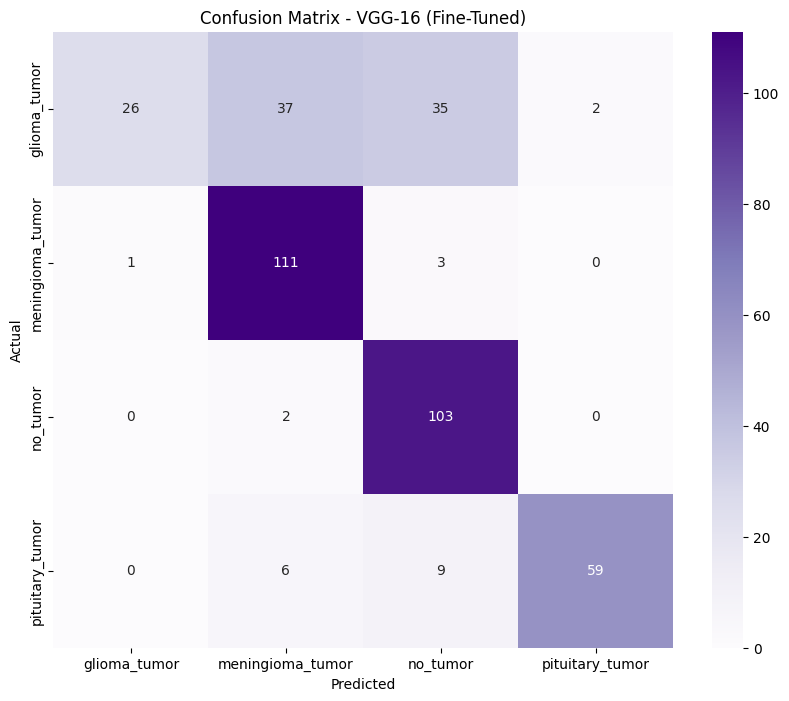

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
import tensorflow as tf


model_path = os.path.join(base_path, 'vgg16_final_fine_tuned.keras')
final_vgg_model = tf.keras.models.load_model(model_path)


class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


test_labels = []
test_preds = []

print("Running inference on test dataset for VGG-16...")
for images, labels in test_ds_vgg:
    preds = final_vgg_model.predict(images, verbose=0)
    test_labels.extend(np.argmax(labels, axis=1))
    test_preds.extend(np.argmax(preds, axis=1))

print("\n--- VGG-16 Classification Report ---")
print(classification_report(test_labels, test_preds, target_names=class_names))


cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - VGG-16 (Fine-Tuned)')
plt.show()

In [ ]:
model_vgg = tf.keras.models.load_model(os.path.join(base_path, 'vgg16_final_fine_tuned.keras'))
print("VGG-16 successfully reloaded.")

VGG-16 successfully reloaded.


Generating predictions for VGG-16...


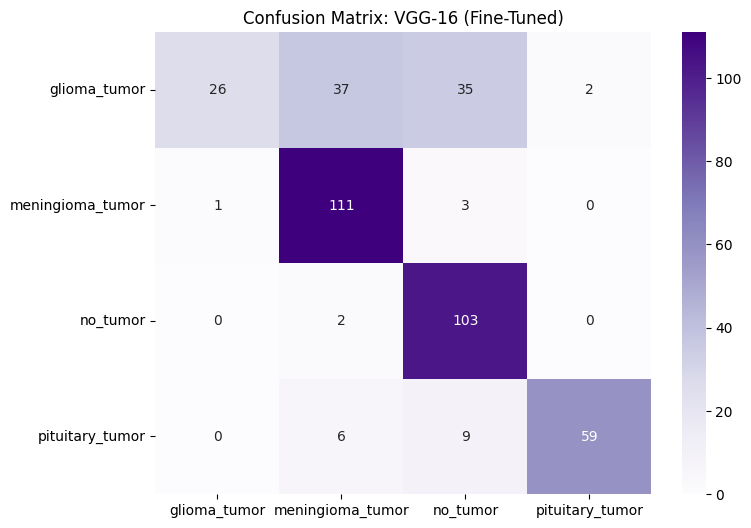

✓ VGG-16 assets saved.


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

def save_vgg_assets(model, test_dataset, save_path):
    print("Generating predictions for VGG-16...")
    test_labels, test_preds = [], []

    for images, labels in test_dataset:
        preds = model.predict(images, verbose=0)
        test_labels.extend(np.argmax(labels, axis=1))
        test_preds.extend(np.argmax(preds, axis=1))


    report = classification_report(test_labels, test_preds, target_names=class_names, output_dict=True)
    pd.DataFrame(report).transpose().to_csv(os.path.join(save_path, 'vgg16_report.csv'))


    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(test_labels, test_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix: VGG-16 (Fine-Tuned)')
    plt.savefig(os.path.join(save_path, 'vgg16_cm.png'), dpi=300)
    plt.show()
    print("✓ VGG-16 assets saved.")

save_vgg_assets(model_vgg, test_ds_vgg, base_path)

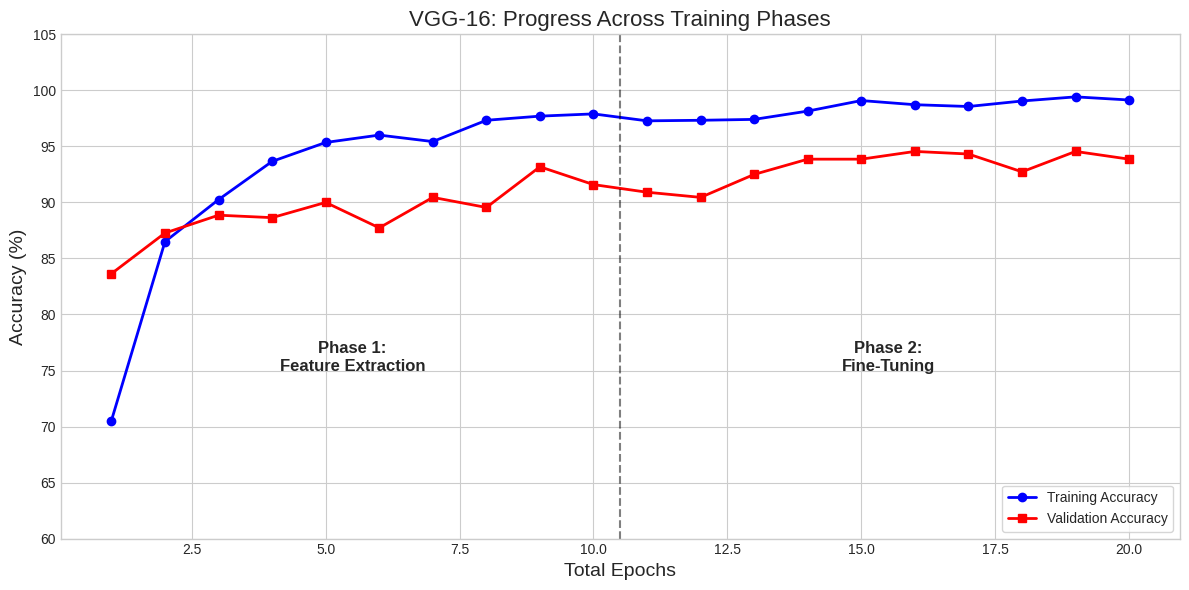

✓ Saved: vgg16_full_lifecycle.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os


vgg_train_acc = [0.7053, 0.8650, 0.9025, 0.9366, 0.9535, 0.9601, 0.9543, 0.9733, 0.9770, 0.9790] + \
                [0.9728, 0.9733, 0.9741, 0.9815, 0.9909, 0.9872, 0.9856, 0.9905, 0.9942, 0.9914]

vgg_val_acc = [0.8364, 0.8727, 0.8886, 0.8864, 0.9000, 0.8773, 0.9045, 0.8955, 0.9318, 0.9159] + \
              [0.9091, 0.9045, 0.9250, 0.9386, 0.9386, 0.9455, 0.9432, 0.9273, 0.9455, 0.9386]

total_epochs = np.arange(1, 21)


plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(total_epochs, [x * 100 for x in vgg_train_acc], 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(total_epochs, [x * 100 for x in vgg_val_acc], 'r-s', label='Validation Accuracy', linewidth=2)


plt.axvline(x=10.5, color='black', linestyle='--', alpha=0.5)
plt.text(5.5, 75, 'Phase 1:\nFeature Extraction', fontsize=12, ha='center', fontweight='bold')
plt.text(15.5, 75, 'Phase 2:\nFine-Tuning', fontsize=12, ha='center', fontweight='bold')

plt.title('VGG-16: Progress Across Training Phases', fontsize=16)
plt.xlabel('Total Epochs', fontsize=14)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.ylim(60, 105)
plt.legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()
plt.savefig(os.path.join(base_path, 'vgg16_full_lifecycle.png'), dpi=300)
plt.show()

print("✓ Saved: vgg16_full_lifecycle.png")